# BNOT quickstart

This notebook exercises the shipped `ibnot_new_cli` backend through the Python wrapper.

In [6]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np

from ibnot_cli_wrapper import (
    find_default_executable,
    make_linear_ramp,
    make_sine_landscape,
    make_uniform,
    run_case,
)

REPO_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "ibnot_cli").exists() and (path / "python").exists()
)
OUTPUT_DIR = REPO_ROOT / "python" / "notebooks" / "_generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIZE = 512
NUM_SITES = 1024
SEED = 7
OUTPUT_WIDTH = SIZE
OUTPUT_HEIGHT = SIZE
POINT_RADIUS = 0.002
DPI = 300
CLI = find_default_executable()
GS = shutil.which("gs")
if GS is None:
    raise RuntimeError("Ghostscript ('gs') is required for notebook PNG previews.")

print(f"Repo root: {REPO_ROOT}")
print(f"CLI: {CLI}")
print(f"Output dir: {OUTPUT_DIR}")

def show_case(title: str, image: np.ndarray, result):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
    axes[0].set_title(f"{title} input")
    axes[0].axis("off")

    rendered = plt.imread(result.png_path)
    axes[1].imshow(rendered)
    axes[1].set_title(f"{title} output")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    print(result.stats)


Repo root: /home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new
CLI: /home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/ibnot_cli/prebuilt/linux-x86_64/ibnot_new_cli
Output dir: /home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated


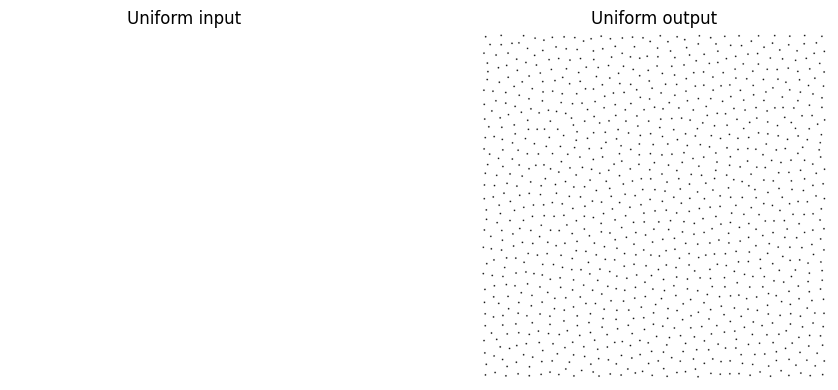

{'image_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/uniform_512_1024_input.pgm', 'output_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/uniform_512_1024.eps', 'stats_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/uniform_512_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'visible_sites': 1024, 'iterations': 2, 'energy': -0.04438753042223675, 'mean_capacity': 0.2490234375, 'mean_abs_capacity_error': 3.689751193916395e-07, 'max_abs_capacity_error': 5.455416633226573e-05, 'rms_abs_capacity_error': 2.252168027335788e-06, 'mean_rel_capacity_error': 1.481688322576623e-06, 'max_rel_capacity_error': 0.0002190724169578043, 'rms_rel_capacity_error': 9.044000235262146e-06}


In [7]:
uniform = make_uniform(size=SIZE, value=1.0)
uniform_result = run_case(
    uniform,
    OUTPUT_DIR,
    "uniform_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    dpi=DPI,
)
show_case("Uniform", uniform, uniform_result)


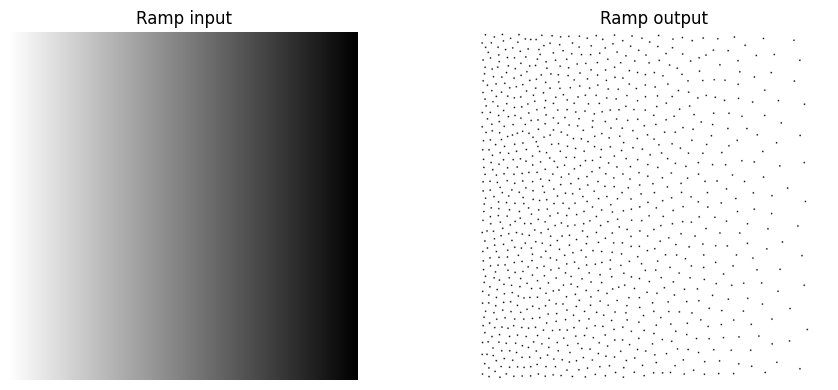

{'image_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/ramp_512_1024_input.pgm', 'output_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/ramp_512_1024.eps', 'stats_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/ramp_512_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'visible_sites': 1024, 'iterations': 2, 'energy': -0.02176757123529635, 'mean_capacity': 0.12451171875, 'mean_abs_capacity_error': 1.419586270534542e-07, 'max_abs_capacity_error': 1.781753476620684e-05, 'rms_abs_capacity_error': 7.836018204036815e-07, 'mean_rel_capacity_error': 1.140122620413624e-06, 'max_rel_capacity_error': 0.0001430992596125161, 'rms_rel_capacity_error': 6.293398149751921e-06}


In [8]:
ramp = make_linear_ramp(size=SIZE, left=1.0, right=0.0)
ramp_result = run_case(
    ramp,
    OUTPUT_DIR,
    "ramp_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    dpi=DPI,
)
show_case("Ramp", ramp, ramp_result)


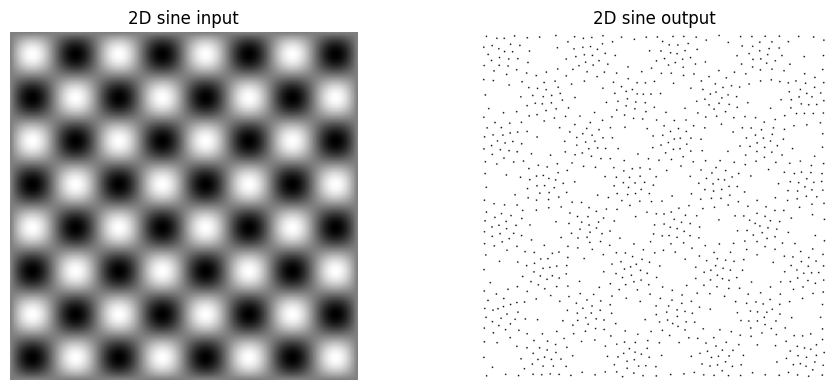

{'image_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/sine2d_256_1024_input.pgm', 'output_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/sine2d_256_1024.eps', 'stats_path': '/home/przem/projects/Ofir_Stippling_Diffusion_Shared/_external/BNOT_new/python/notebooks/_generated/sine2d_256_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'visible_sites': 1024, 'iterations': 3, 'energy': -0.02068674560901935, 'mean_capacity': 0.1245156526565552, 'mean_abs_capacity_error': 4.592777693699951e-08, 'max_abs_capacity_error': 5.757572858117177e-06, 'rms_abs_capacity_error': 2.701309295392293e-07, 'mean_rel_capacity_error': 3.688514331903285e-07, 'max_rel_capacity_error': 4.62397516720085e-05, 'rms_rel_capacity_error': 2.169453588974206e-06}


In [9]:
sine = make_sine_landscape(size=SIZE, fx=4, fy=4)
sine_result = run_case(
    sine,
    OUTPUT_DIR,
    "sine2d_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    dpi=DPI,
)
show_case("2D sine", sine, sine_result)
